In [1]:
!pip install fastf1 tensorflow scikit-learn matplotlib seaborn pandas numpy plotly

import fastf1
import tensorflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import plotly.express as px
import plotly.graph_objects as go
import warnings
import os

# Decide the style of the project
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Create a cache for the FastF1 Data for faster load times
cache_dir = 'cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
fastf1.Cache.enable_cache(cache_dir) 

def load_f1_session_data(year=2024, round_number=1): # CHANGE TO INCLUDE QUALIFYING AND PRACTICE
    try: 
        session = fastf1.get_session(year, round_number, 'R') #CHANGE TO INCLUDE QUALI
        session.load()

        # Get Lap Data
        laps = session.laps

        #Get Weather Data
        weather = session.weather_data

        #Get Session Results
        results = session.results

        print(f"Data Loaded Successfully for {session.event['EventName']} {year}")
        print(f"    -Laps: {len(laps)}")
        print(f"    -Weather Data Points: {len(weather)}")
        print(f"    -Drivers: {len(results)}")

        return session, laps, weather, results
    except Exception as exception:
        print(f"Error Loading Data: {exception}")
        return None, None, None, None

In [3]:
year = int(input('What Year?: '))

session, laps, weather, results = load_f1_session_data(year, 1)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core    

Data Loaded Successfully for Australian Grand Prix 2025
    -Laps: 927
    -Weather Data Points: 178
    -Drivers: 20


In [4]:
def create_comprehensive_dataset(laps, weather, results):
    #Basic Lap Data
    lap_data = laps[['Driver', 'LapNumber', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Compound']].copy()

    #Convert Laptimes to seconds
    lap_data['LapTimeSeconds'] = lap_data['LapTime'].dt.total_seconds()
    lap_data['Sector1Seconds'] = lap_data['Sector1Time'].dt.total_seconds()
    lap_data['Sector2Seconds'] = lap_data['Sector2Time'].dt.total_seconds()
    lap_data['Sector3Seconds'] = lap_data['Sector3Time'].dt.total_seconds()

    #Remove invlalid laps (outliers)
    lap_data = lap_data.dropna(subset=['LapTimeSeconds'])
    lap_data = lap_data[lap_data['LapTimeSeconds'] > 60]
    lap_data = lap_data[lap_data['LapTimeSeconds'] < 150]

    #Add Tire Age
    lap_data['TireAge'] = lap_data.groupby(['Driver', 'Compound']).cumcount() + 1

    # Add Position data if possible
    if 'Position' in laps.columns:
        lap_data['Position'] = laps['Position']
    
    # Encode categorical variables
    le_driver = LabelEncoder()
    le_compound = LabelEncoder()

    lap_data['DriverEncoded'] = le_driver.fit_transform(lap_data['Driver'])
    lap_data['CompoundEncoded'] = le_compound.fit_transform(lap_data['Compound'])

    # Add Weather Features
    if len(weather) > 0:
        avg_track_temp = weather['TrackTemp'].mean()
        lap_data['TrackTemp'] = avg_track_temp
    else:
        lap_data['TrackTemp'] = 45
    
    print(f"Comprehensive Dataset Created with {len(lap_data)} valid laps!")
    print(f"    - Features: {lap_data.columns.to_list()}")

    return lap_data, le_driver, le_compound

In [5]:
# Create the Comprehensive Dataset
if laps is not None:
    df, driver_encoder, compound_encoder = create_comprehensive_dataset(laps, weather, results)


Comprehensive Dataset Created with 858 valid laps!
    - Features: ['Driver', 'LapNumber', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Compound', 'LapTimeSeconds', 'Sector1Seconds', 'Sector2Seconds', 'Sector3Seconds', 'TireAge', 'Position', 'DriverEncoded', 'CompoundEncoded', 'TrackTemp']



DATASET STATISTICS:
       LapTimeSeconds     SpeedFL     TireAge
count      858.000000  831.000000  858.000000
mean       103.638020  271.107100   18.245921
std         18.624009   29.648411   12.658107
min         82.167000  123.000000    1.000000
25%         91.044000  277.000000    7.000000
50%         93.499500  281.000000   16.000000
75%        120.455750  285.000000   29.000000
max        149.413000  310.000000   48.000000


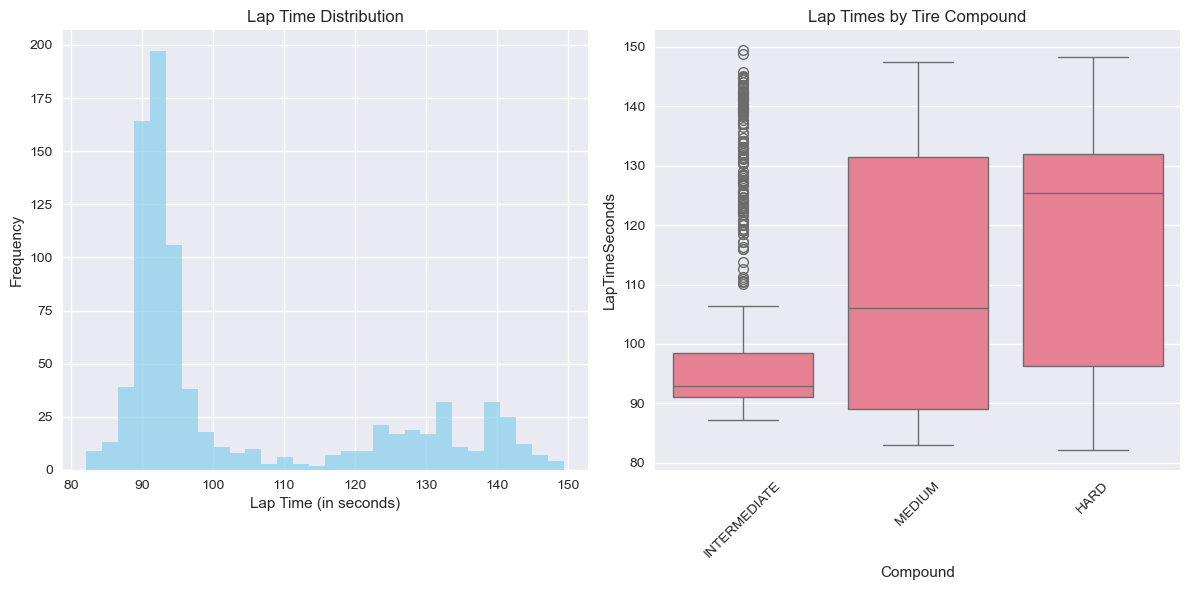

In [6]:
# Display the Basic Stats
print("\nDATASET STATISTICS:")
print(df[['LapTimeSeconds', 'SpeedFL', 'TireAge']].describe())

#Visualize lap time distribution
plt.figure(figsize=(12,6))

plt.subplot(1, 2, 1)
plt.hist(df['LapTimeSeconds'], bins=30, alpha=0.7, color='skyblue')
plt.title('Lap Time Distribution')
plt.xlabel('Lap Time (in seconds)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Compound', y='LapTimeSeconds')
plt.title('Lap Times by Tire Compound')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [7]:
def create_lap_time_model(input_dim):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='linear') # Regression output
    ])

    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

def train_lap_time_predictor(df):
    feature_cols = ['LapNumber', 'DriverEncoded', 'CompoundEncoded', 'TireAge', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'TrackTemp']
    model_data = df[feature_cols + ['LapTimeSeconds']].dropna()

    if len(model_data) < 50:
        print('Not enough trading data!')
        return None, None, None
    
    x = model_data[feature_cols]
    y = model_data['LapTimeSeconds']

    #Split the Data
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

    #Scale the Features
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    # Create and train the model
    model = create_lap_time_model(x_train_scaled.shape[1])

    print("Training Lap Time Prediction Model...")
    history = model.fit(
        x_train_scaled, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    # Make Predictions
    y_pred = model.predict(x_test_scaled)

    # Calculate Metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f"Model trained successfully!")
    print(f"   - RMSE: {rmse:.3f} seconds")
    print(f"   - Mean lap time: {y_test.mean():.3f} seconds")
    print(f"   - Prediction accuracy: {((rmse/y_test.mean())*100):.2f}% error")

    # Plot training history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Lap Time (s)')
    plt.ylabel('Predicted Lap Time (s)')
    plt.title(f'Predictions vs Actual (RMSE: {rmse:.3f}s)')

    plt.tight_layout()
    plt.show()

    return model, scaler, feature_cols

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Lap Time Prediction Model...
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Model trained successfully!
   - RMSE: 7.527 seconds
   - Mean lap time: 103.461 seconds
   - Prediction accuracy: 7.28% error


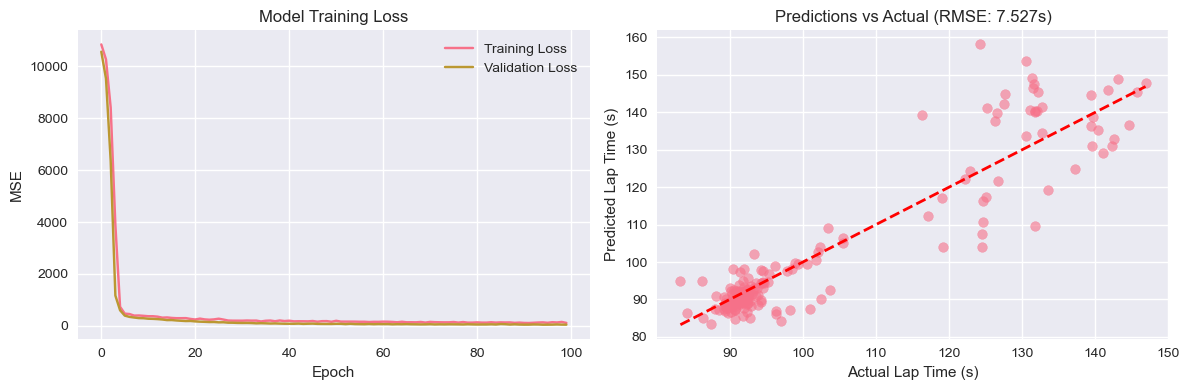

In [8]:
# Train the lap time predictor
if 'df' in locals() and len(df) > 0:
    lap_time_model, lap_time_scaler, lap_time_features = train_lap_time_predictor(df)

In [12]:
def create_race_outcome_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax') # Classification output
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def prepare_race_outcome_data(df):
    driver_stats = df.groupby('Driver').agg({
        'LapTimeSeconds': ['mean', 'std', 'min'],
        'SpeedFL': ['mean', 'max'],
        'TireAge': 'max',
        'LapNumber': 'max'
    }).round(3)

    # Flatten Column names
    driver_stats.columns = ['_'.join(col).strip() for col in driver_stats.columns]
    driver_stats = driver_stats.reset_index()

    # Create finishing position classes
    if results is not None and len(results) > 0:
        race_results = results[['Abbreviation', 'Position']].copy()
        race_results.columns = ['Driver', 'FinishPosition']

        driver_stats = driver_stats.merge(race_results, on='Driver', how='left')

        # Create outcome classes
        def classify_result(position):
            if pd.isna(position):
                return 2
            elif position <= 3:
                return 0
            elif position <= 10:
                return 1
            else:
                return 2
            
        driver_stats['OutcomeClass'] = driver_stats['FinishPosition'].apply(classify_result)

        return driver_stats
    else:
        # Simulate outcome based on performance if no results available
        driver_stats['OutcomeClass'] = pd.cut(
            driver_stats['LapTimeSeconds_mean'],
            bins=3,
            labels=[0, 1, 2]
        ).astype(int)

        return driver_stats

def train_race_outcome_predictor(driver_stats):
    feature_cols = [col for col in driver_stats.columns
                   if col not in ['Driver', 'FinishPosition', 'OutcomeClass']]

    X = driver_stats[feature_cols]
    y = driver_stats['OutcomeClass']

    if len(X) < 10:
        print("Not enough drivers for race outcome prediction")
        return None, None, None

    # Handle missing values
    X = X.fillna(X.mean())

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Scale the features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Create and train the model
    num_classes = len(y.unique())
    model = create_race_outcome_model(X_train_scaled.shape[1], num_classes)

    print("Training Race Outcome Prediction Model...")
    history = model.fit(
        X_train_scaled, y_train,
        epochs=150,
        batch_size=8,
        validation_split=0.2,
        verbose=0
    )

    # Make predictions
    y_pred_proba = model.predict(X_test_scaled)
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Race Outcome Model trained!")
    print(f"   - Accuracy: {accuracy:.3f}")
    print(f"   - Classes: 0=Podium, 1=Points, 2=No Points")

    # Classification report
    class_names = ['Podium', 'Points', 'No Points']
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    return model, scaler, feature_cols

# Train race outcome predictor
if 'df' in locals() and len(df) > 0:
    race_stats = prepare_race_outcome_data(df)
    print(f"\nRace Statistics for {len(race_stats)} drivers:")
    print(race_stats.head())

    race_outcome_model, race_outcome_scaler, race_outcome_features = train_race_outcome_predictor(race_stats)


Race Statistics for 17 drivers:
  Driver  LapTimeSeconds_mean  LapTimeSeconds_std  LapTimeSeconds_min  \
0    ALB              104.672              19.327              84.597   
1    ALO               98.517              15.631              88.819   
2    ANT              104.579              19.296              84.901   
3    BEA              103.870              17.243              87.603   
4    BOR              102.656              17.920              84.192   

   SpeedFL_mean  SpeedFL_max  TireAge_max  LapNumber_max  FinishPosition  \
0       275.423        310.0           43           57.0             5.0   
1       274.207        293.0           29           32.0            17.0   
2       274.673        306.0           43           57.0             4.0   
3       263.392        286.0           48           57.0            14.0   
4       268.641        289.0           31           45.0            16.0   

   OutcomeClass  
0             1  
1             2  
2             1  

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Race Outcome Model trained!
   - Accuracy: 0.500
   - Classes: 0=Podium, 1=Points, 2=No Points

Classification Report:
              precision    recall  f1-score   support

      Podium       0.00      0.00      0.00         0
      Points       0.50      1.00      0.67         2
   No Points       1.00      0.25      0.40         4

    accuracy                           0.50         6
   macro avg       0.50      0.42      0.36         6
weighted avg       0.83      0.50      0.49         6



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
